In [1]:
from fastbook import *
from fastai.vision.widgets import *

In [37]:
projektName = 'cool oder uncool'
kategorie1 = 'cool'
kategorie2 = 'uncool'

In [38]:
#laden der bilder in fns
path = Path(f'Beispiel-Modelle/Trainingsdaten/{projektName}/')
fns = get_image_files(path)
#gibt liste von failed downloaded images
failed = verify_images(fns)
print(f"Es gab {len(failed)} fehlerhafte Downloads. Ich behebe das automatisch!")
#unlink the failed downloaded images
failed.map(Path.unlink)
print(path)

Es gab 0 fehlerhafte Downloads. Ich behebe das automatisch!
Beispiel-Modelle/Trainingsdaten/cool oder uncool


In [39]:
daten = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(128))
daten

In [40]:
dls = daten.dataloaders(path)
print(dls.vocab)

['cool', 'uncool']


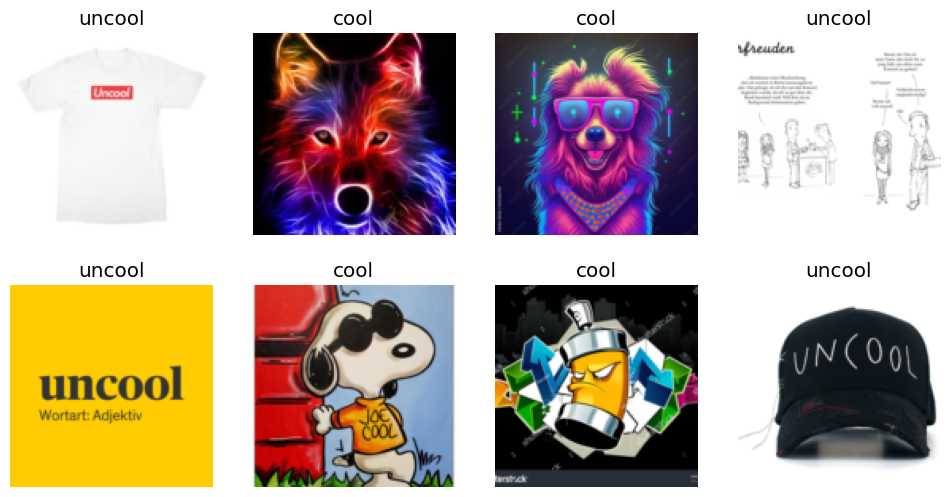

In [41]:
dls.valid.show_batch(max_n=8, nrows=2)

In [42]:
daten = daten.new(
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=aug_transforms())
dls = daten.dataloaders(path)

In [43]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,1.518846,1.231058,0.521739,00:02


/home/marcel/.kiVerstehen2/lib/python3.12/site-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/marcel/.kiVerstehen2/lib/python3.12/site-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/marcel/.kiVerstehen2/lib/python3.12/site-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,error_rate,time
0,0.810564,0.849110,0.391304,00:02
1,0.690039,0.455462,0.195652,00:02
2,0.569759,0.264139,0.086957,00:02
3,0.488042,0.207204,0.086957,00:02


/home/marcel/.kiVerstehen2/lib/python3.12/site-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/marcel/.kiVerstehen2/lib/python3.12/site-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/marcel/.kiVerstehen2/lib/python3.12/site-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/marcel/.kiVerstehen2/lib/python3.12/site-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/marcel/.kiVerstehen2/lib/python3.12/site-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/marcel/.kiVerstehen2/lib/python3.1

In [44]:
#export model as .pkl
learn.export()

In [47]:
#load pkl-model
learn_inf = load_learner('Beispiel-Modelle/Modelle/cool oder uncool-linux.pkl')

In [48]:
#predict for image 'blabla.jpeg'
#learn = load_learner('model.pkl')
img = PILImage.create('Beispiel-Modelle/Testbilder/katze.jpg') 
pred,pred_idx,probs = learn_inf.predict(img)